# Risk Score Analysis & Empirical Consistency Check

<br><br>

## 0. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_fire_df, load_risk_df

<br><br>

## 1. Setup & Data

In [ ]:
fire = load_fire_df()
risk = load_risk_df()

In [14]:
# Define risk bins
bin_size = 0.1
bin_edges = np.round(np.arange(0.0, 1.0 + bin_size, bin_size), 10)
bin_labels = [f'{bin_edges[i]:.1f}-{bin_edges[i+1]}' for i in range(len(bin_edges) - 1)]

In [15]:
# Define window sizes
w_values = [24, 48, 72]

In [16]:
# Helper function to mark if cells are active within next w hours
def add_future_fire_label(risk: pd.DataFrame, fire: pd.DataFrame, w: int) -> pd.DataFrame:
    # Build (h3_id, t) where fire occurs between t and t + w
    offsets = pd.to_timedelta(np.arange(1, w + 1), unit = 'h')
    offsets_df = pd.DataFrame({'offset': offsets, 'key': 1})

    future_hits = (
        fire.assign(key = 1)
        .merge(offsets_df, on = 'key', how = 'inner')
        .drop(columns = 'key')
    )

    future_hits['hour_bin'] = future_hits['hour_bin'] - future_hits['offset']
    future_hits = future_hits[['h3_id', 'hour_bin']].drop_duplicates()
    future_hits['future_fire'] = 1

    # Censor training period where w can't be observed
    max_fire_time = fire['hour_bin'].max()
    valid_risk = risk[risk['hour_bin'] <= (max_fire_time - pd.Timedelta(hours = 72))].copy()

    labeled = valid_risk.merge(future_hits, on = ['h3_id', 'hour_bin'], how = 'left')
    labeled['future_fire'] = labeled['future_fire'].fillna(0).astype(int)
    return labeled

# Function to get fire proportions
def get_fire_proportions(risk: pd.DataFrame, fire: pd.DataFrame) -> pd.DataFrame:
    # Compute tables
    rows = []

    for w in w_values:
        df_h = add_future_fire_label(risk, fire, w)

        df_h['risk_bin'] = pd.cut(
            df_h['risk'],
            bins = bin_edges,
            labels = bin_labels,
            include_lowest = False,
            right = True
        )
        df_h = df_h.dropna(subset = ['risk_bin']).copy()

        summary = (
            df_h.groupby('risk_bin', observed = True)
            .agg(
                n = ('future_fire', 'size'),
                n_future_fire = ('future_fire', 'sum'),
                rate = ('future_fire', 'mean'),
                risk_mean = ('risk', 'mean')
            )
            .reset_index()
        )

        baseline = df_h['future_fire'].mean()
        summary['baseline_rate'] = baseline
        summary['lift_vs_baseline'] = np.where(baseline > 0, summary['rate'] / baseline, np.nan)
        summary['horizon_h'] = w

        rows.append(summary)

    return pd.concat(rows, ignore_index = True)

# Helper function to compute summary table
def get_pivot_table(results: pd.DataFrame) -> pd.DataFrame:
    # Extract n columns
    n = results.loc[results['horizon_h'] == 24, 'n'].copy()

    pivot = results.pivot_table(
        index = 'risk_bin',
        columns = 'horizon_h',
        values = 'rate'
    ).sort_index()

    pivot['n'] = n.values

    return pivot

<br><br>

## 2. Fire Onset Probabilities

In [17]:
proportions = get_fire_proportions(risk, fire)
proportions_table = get_pivot_table(proportions)
proportions_table

/var/folders/w1/ftfbr5xs18x1zlwfq09kkxgm0000gn/T/ipykernel_70152/3695977330.py:67: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results.pivot_table(


horizon_h,24,48,72,n
risk_bin,,,,
0.0-0.1,0.000844,0.002071,0.004130,1398509
0.1-0.2,0.002683,0.006891,0.010181,182991
0.2-0.3,0.019049,0.043498,0.057291,48140
0.3-0.4,0.103595,0.179605,0.207596,19721
0.4-0.5,0.209520,0.304598,0.339205,8004
0.5-0.6,0.316077,0.388598,0.429445,4578
0.6-0.7,0.463226,0.559212,0.587135,4011
0.7-0.8,0.643496,0.653659,0.655691,2460
0.8-0.9,0.637636,0.688958,0.706065,643


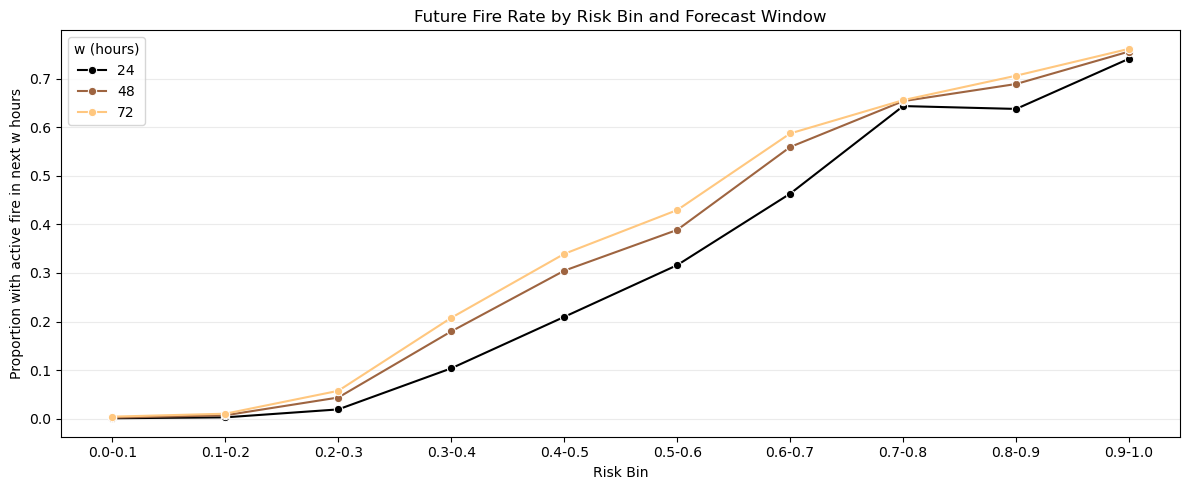

In [18]:
# Plot
plt.figure(figsize = (12, 5))
sns.lineplot(
    data = proportions,
    x = 'risk_bin',
    y = 'rate',
    hue = 'horizon_h',
    marker = 'o',
    palette = 'copper'
)
plt.xlabel('Risk Bin')
plt.ylabel('Proportion with active fire in next w hours')
plt.title('Future Fire Rate by Risk Bin and Forecast Window')
plt.grid(axis = 'y', alpha = 0.25)
plt.legend(title = 'w (hours)')
plt.tight_layout()
plt.show()

<br><br>

## 3. Fire Onset Probabilities (Excluding Currently Active)

In [19]:
# Mark currently active fires
fire_now = fire.copy()
fire_now['active_now'] = 1

# Exclude currently active cell-hours
risk_inactive = risk.merge(fire_now, on = ['h3_id', 'hour_bin'], how = 'left')
risk_inactive = risk_inactive[risk_inactive['active_now'].fillna(0) == 0].drop(columns = ['active_now']).copy()

In [20]:
# Compute tables
proportions_inactive = get_fire_proportions(risk_inactive, fire)
proportions_inactive_table = get_pivot_table(proportions_inactive)
print(proportions_inactive_table)

horizon_h        24        48        72        n
risk_bin                                        
0.0-0.1    0.000841  0.002067  0.004127  1398499
0.1-0.2    0.002683  0.006891  0.010181   182991
0.2-0.3    0.018967  0.043399  0.057193    48135
0.3-0.4    0.102808  0.178910  0.206935    19697
0.4-0.5    0.208025  0.303323  0.338056     7975
0.5-0.6    0.311003  0.384206  0.425466     4508
0.6-0.7    0.451289  0.549485  0.578093     3880
0.7-0.8    0.629730  0.639640  0.641441     2220
0.8-0.9    0.619211  0.672384  0.691252      583
0.9-1.0    0.733333  0.747458  0.753672     1770


/var/folders/w1/ftfbr5xs18x1zlwfq09kkxgm0000gn/T/ipykernel_70152/3695977330.py:67: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results.pivot_table(


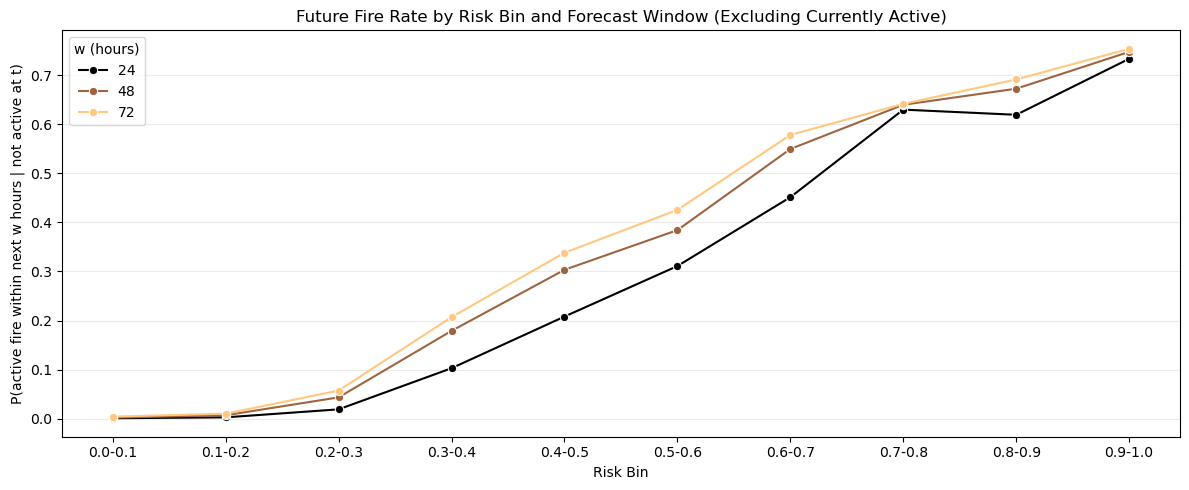

In [33]:
# Plot
plt.figure(figsize = (12, 5))
sns.lineplot(
    data = proportions_inactive,
    x = 'risk_bin',
    y = 'rate',
    hue = 'horizon_h',
    marker = 'o',
    palette = 'copper'
)
plt.xlabel('Risk Bin')
plt.ylabel('P(active fire within next w hours | not active at t)')
plt.title('Future Fire Rate by Risk Bin and Forecast Window (Excluding Currently Active)')
plt.grid(axis = 'y', alpha = 0.25)
plt.legend(title = 'w (hours)')
plt.tight_layout()
plt.show()

In [38]:
# Compute fraction of all future fires with R > 0 for each w
recall_from_fire = []
for w in w_values:
    offsets = pd.to_timedelta(np.arange(1, w + 1), unit = 'h')

    expanded = (
        fire.assign(key = 1)
        .merge(pd.DataFrame({'offset': offsets, 'key': 1}), on = 'key')
        .drop(columns = 'key')
    )
    expanded['hour_bin_prev'] = expanded['hour_bin'] - expanded['offset']
    # Check if any of these are in the risk table
    merged = expanded.merge(
        risk[['h3_id', 'hour_bin']],
        left_on=['h3_id', 'hour_bin_prev'],
        right_on=['h3_id', 'hour_bin'],
        how='left',
        indicator=True
    )
    # For each fire event, find amount of its w preceding cell-hours with R > 0
    captured = merged.groupby(['h3_id', 'hour_bin_x'])['_merge'].apply(lambda x: (x == 'both').any())
    recall = captured.mean()
    recall_from_fire.append({'horizon_h': w, 'recall': recall, 'n_total': captured.size, 'n_captured': captured.sum()})

recall_from_fire_df = pd.DataFrame(recall_from_fire)
print(recall_from_fire_df)

   horizon_h    recall  n_total  n_captured
0         24  0.109178    10176        1111
1         48  0.131879    10176        1342
2         72  0.153498    10176        1562
